In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("../data/processed/nba_stats_clean.csv")

print(df.shape)
print(df.columns.tolist())

(6708, 29)
['season', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs', 'mp', 'per', 'ts_percent', 'x3p_ar', 'f_tr', 'orb_percent', 'drb_percent', 'trb_percent', 'ast_percent', 'stl_percent', 'blk_percent', 'tov_percent', 'usg_percent', 'ows', 'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp']


In [3]:
df_c = df[df['pos'] == 'C'].copy()

print("Nombre de C :", df_c.shape[0])

Nombre de C : 1230


On utilise les statistiques préselectionnées.

In [4]:
c_stats = [
    "orb_percent",
    "drb_percent",
    "blk_percent",
    "ast_percent",
    "x3p_ar",
    "ts_percent",
    "usg_percent",
]
X_c = df_c[c_stats]

On met les stastiques à la même échelle avant d'éviter une influence excessive des données brutes des données relatives.

In [5]:
scaler = StandardScaler()
X_c_scaled = scaler.fit_transform(X_c)

On utilise les PCA (Principal Component Analysis) pour résumer les statistiques utilisés en quelques axes synthétiques et ainsi pouvoir visualiser quelles statistiques permettent de classer les joueurs. On fixe la variance cumulée au moins à 0,7 afin d'être suffisament précis pour classer les joueurs de façons pertinentes sans rentrer dans des groupes ultra spécifiques.

In [6]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X_c_scaled)

explained_var = pca.explained_variance_ratio_

cumulative_var = np.cumsum(explained_var)

print(explained_var)
print(cumulative_var)

[0.29175456 0.22379755 0.15498816 0.12815437 0.08440292 0.06696935
 0.04993309]
[0.29175456 0.51555212 0.67054028 0.79869465 0.88309756 0.95006691
 1.        ]


On prendra donc 4 PCA pour les C. 

In [7]:
pca = PCA(n_components=3, random_state=42)
pca_result = pca.fit_transform(X_c_scaled)

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PCA{i+1}' for i in range(pca.n_components_)],
    index=c_stats
)

print("Loadings PCA :")
print(loadings)

Loadings PCA :
                 PCA1      PCA2      PCA3
orb_percent  0.510586  0.390289 -0.133978
drb_percent  0.006818  0.675159  0.039571
blk_percent  0.270804  0.009254  0.533827
ast_percent -0.471274  0.368417  0.063436
x3p_ar      -0.480998 -0.260858  0.359087
ts_percent   0.165430  0.123965  0.750014
usg_percent -0.430227  0.415455 -0.004918


On cherche à determiner le nombre de clusters le plus pertinent pour le poste à l'aide de la méthode du coude et du score de silouhette .

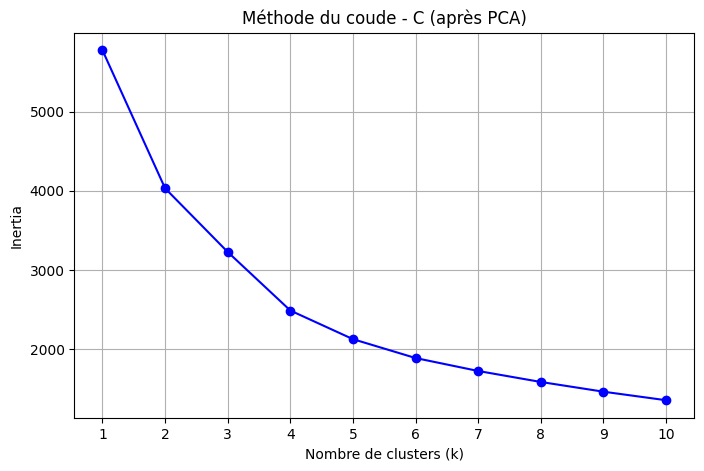

In [8]:
inertia_list = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(pca_result)  
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_list, 'o-', color='blue')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Méthode du coude - C (après PCA)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [9]:
inertia_c = pd.DataFrame({'k': k_values, 'inertia': inertia_list})
inertia_c

,k,inertia
0,1,5773.351774
1,2,4031.707191
2,3,3228.502968
3,4,2489.942029
4,5,2128.708184
5,6,1890.542316
6,7,1727.185655
7,8,1588.702173
8,9,1465.982928
9,10,1358.505564


In [15]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pandas as pd


silhouette_scores = []


for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(pca_result)  # <- utiliser le résultat PCA
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)


silhouette_df = pd.DataFrame({
    'k': range(2, 11),
    'silhouette_score': silhouette_scores
})

silhouette_df


,k,silhouette_score
0,2,0.311184
1,3,0.252586
2,4,0.292113
3,5,0.277390
4,6,0.265340
5,7,0.251986
6,8,0.258860
7,9,0.256564
8,10,0.260417


In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df_c['cluster'] = kmeans.fit_predict(pca_result)

Le nombre de clusters a été déterminé à l’aide de la méthode du coude et du score de silhouette. Le score de silouhette est le plus élévé pour k=4.Nous étudierons donc 4 clusters.

In [11]:
cluster_means = df_c.groupby('cluster')[c_stats].mean()
cluster_means

,orb_percent,drb_percent,blk_percent,ast_percent,x3p_ar,ts_percent,usg_percent
cluster,,,,,,,
0,12.561027,23.781269,4.961329,6.999698,0.032731,0.639828,15.562236
1,10.497639,20.355365,3.220172,7.799142,0.031841,0.547453,16.586910
2,10.142601,27.492825,3.271300,16.753812,0.103260,0.578359,24.849327
3,6.139048,19.497143,3.335714,11.345238,0.404938,0.581771,19.150000


Cluster 0 — Rim Protector Efficient
Très forte efficacité offensive (TS% très élevé).Gros impact au rebond offensif et défensif.Très forte protection du cercle (BLK% élevé).Faible création de jeu et très peu de tirs à 3 points.
Cluster 1 — Pivot traditionnel
Contribution équilibrée au rebond.Protection du cercle correcte mais moins dominante.
Très faible tir extérieur.Impact offensif limité.
Cluster 2 — Pivot playmaker / star
Usage offensif très élevé (USG% ~25).Très forte création de jeu (AST% très élevé pour un pivot).Très fort rebond défensif.Bonne efficacité offensive.
Cluster 3 — Stretch Center
Très forte proportion de tirs à 3 points (3P_AR très élevé).Bonne efficacité offensive.
Rebond offensif plus faible.

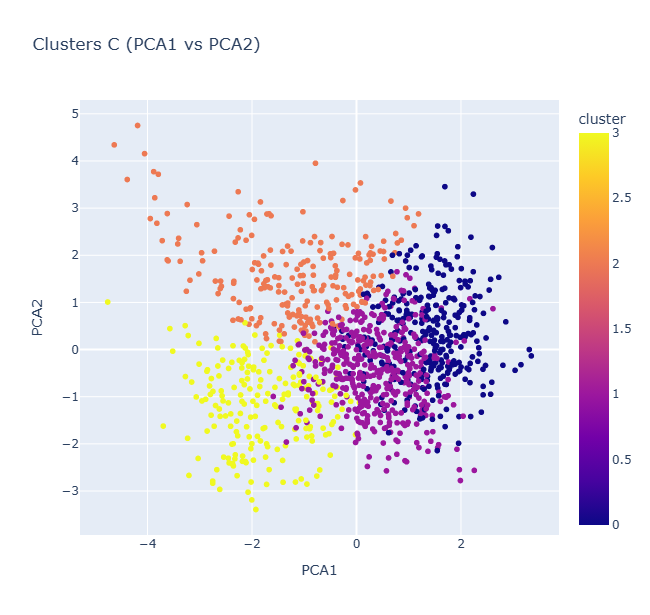

In [12]:
import plotly.express as px
import pandas as pd


plot_df = pd.DataFrame({
    'PCA1': pca_result[:, 0],
    'PCA2': pca_result[:, 1],
    'cluster': df_c['cluster'],
    'player': df_c['player'],
    'team': df_c['team'],
    'season': df_c['season']
})

fig = px.scatter(
    plot_df,
    x='PCA1',
    y='PCA2',
    color='cluster',
    hover_data=['player', 'team', 'season'],
    title="Clusters C (PCA1 vs PCA2)",
    width=900,
    height=600
)

fig.show()

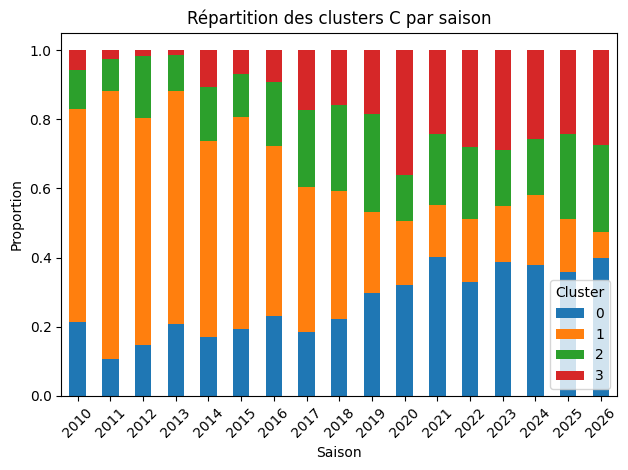

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df_c = pd.read_csv("../data/processed/nba_c_clusters_full.csv")

counts = df_c.groupby(['season', 'cluster']).size().reset_index(name='count')

totals = df_c.groupby('season').size().reset_index(name='total')

counts = counts.merge(totals, on='season')
counts['proportion'] = counts['count'] / counts['total']

pivot = counts.pivot(index='season', columns='cluster', values='proportion')

pivot.plot(kind='bar', stacked=True)

plt.title("Répartition des clusters C par saison")
plt.xlabel("Saison")
plt.ylabel("Proportion")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

On constate une large évolution des profils ces 15 dernières années. Si les C de type 1 étaient largement majoritaires en 2010, ils ont progressivement disparus au cours des 15 dernières années. En revanche, les C de type 0 et 3 sont passés de quasi inexistants a très présents de nos jours. Le second cluster est resté constant durant cette période. 

In [14]:
df_c['cluster'] = kmeans.fit_predict(pca_result)

df_c.to_csv("../data/processed/nba_c_clusters_full.csv", index=False)